In [1]:
# Cell 1 — Imports and config
# CM3015 Breast Cancer Detection
# Notebook 08: Stacking Ensemble
# Base models selected on validated per-model performance (not blanket Optuna):
#   - EfficientNet-B0: Optuna-tuned (Stage 2 head) — tuning improved sensitivity
#     and ECE with only a small specificity trade-off (see NB07 Cell 15)
#   - Swin-T: baseline/untuned — Optuna degraded F1, specificity, FPR and ECE
#     relative to the NB05 baseline (see NB07 Cell 15); baseline is the
#     stronger validated configuration for this backbone

import sys
sys.path.append('/kaggle/input/datasets/mfjmrizvi/cbis-ddsm-project-config')

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import timm

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, confusion_matrix
from sklearn.calibration import calibration_curve

from abmil_common import (
    PatchClassifier, AttentionPool, BagClassifier,
    CachedBagDataset, collate_cached, extract_features,
    compute_all_metrics, build_backbone, PatchDataset,
    get_normalisation_tensors
)

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"timm    : {timm.__version__}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

_mean_gpu, _std_gpu = get_normalisation_tensors(DEVICE)

PyTorch : 2.10.0+cu128
CUDA    : True
timm    : 1.0.26


In [2]:
# Cell 2 — Paths
# VERIFY: NB07 folder slug — replace if your Kaggle notebook path differs
NB02 = Path("/kaggle/input/notebooks/mfjmrizvi/02-mil-patch-extraction")
NB03 = Path("/kaggle/input/notebooks/mfjmrizvi/03-efficientnet-b0")
NB05 = Path("/kaggle/input/notebooks/mfjmrizvi/05-swint")
NB07 = Path("/kaggle/input/notebooks/mfjmrizvi/07-optuna")
OUT  = Path("/kaggle/working")

X_TRAIN_PATH       = NB02 / "X_train_patches.npy"
Y_TRAIN_PATH       = NB02 / "y_train_labels.npy"
BAG_IDS_TRAIN_PATH = NB02 / "bag_ids_train.npy"
TRAIN_BAG_IDX_PATH = NB02 / "train_bag_indices.npy"
VAL_BAG_IDX_PATH   = NB02 / "val_bag_indices.npy"
X_TEST_PATH        = NB02 / "X_test_patches.npy"
Y_TEST_PATH        = NB02 / "y_test_labels.npy"
BAG_IDS_TEST_PATH  = NB02 / "bag_ids_test.npy"

# EfficientNet-B0 — Stage 1 backbone unchanged from NB03; Optuna-tuned Stage 2 head from NB07
EFFNET_S1_WEIGHTS       = NB03 / "efficientnet_b0_stage1.pth"
EFFNET_S2_OPTUNA_WEIGHTS = NB07 / "effnet_b0_optuna_stage2.pth"
EFFNET_OPTUNA_RESULTS_JSON = NB07 / "effnet_b0_optuna_results.json"

# Swin-T — baseline/untuned, both stages from NB05
SWINT_S1_WEIGHTS = NB05 / "swin_t_stage1.pth"
SWINT_S2_WEIGHTS = NB05 / "swin_t_stage2.pth"

RESULTS_JSON = OUT / "nb08_ensemble_results.json"

for p in [X_TRAIN_PATH, EFFNET_S1_WEIGHTS, EFFNET_S2_OPTUNA_WEIGHTS,
          EFFNET_OPTUNA_RESULTS_JSON, SWINT_S1_WEIGHTS, SWINT_S2_WEIGHTS]:
    print(f"{'✓' if p.exists() else '✗ MISSING'}  {p}")

✓  /kaggle/input/notebooks/mfjmrizvi/02-mil-patch-extraction/X_train_patches.npy
✓  /kaggle/input/notebooks/mfjmrizvi/03-efficientnet-b0/efficientnet_b0_stage1.pth
✓  /kaggle/input/notebooks/mfjmrizvi/07-optuna/effnet_b0_optuna_stage2.pth
✓  /kaggle/input/notebooks/mfjmrizvi/07-optuna/effnet_b0_optuna_results.json
✓  /kaggle/input/notebooks/mfjmrizvi/05-swint/swin_t_stage1.pth
✓  /kaggle/input/notebooks/mfjmrizvi/05-swint/swin_t_stage2.pth


In [3]:
# Cell 3 — Load EfficientNet-B0 Optuna hyperparameters from NB07's saved results
# (avoids re-typing values by hand — pulls attn_dim/dropout straight from the
# JSON NB07 already wrote, so this notebook can't silently drift out of sync)
with open(EFFNET_OPTUNA_RESULTS_JSON) as f:
    effnet_optuna_results = json.load(f)

EFFNET_MODEL_NAME = "efficientnet_b0"
EFFNET_FEAT_DIM   = effnet_optuna_results["feat_dim"]
EFFNET_ATTN_DIM   = effnet_optuna_results["optuna_best_params"]["attn_dim"]
EFFNET_DROPOUT    = effnet_optuna_results["optuna_best_params"]["dropout"]
EFFNET_THRESHOLD  = effnet_optuna_results["optimal_threshold"]

print("EfficientNet-B0 (Optuna-tuned) config loaded from NB07:")
print(f"  attn_dim  : {EFFNET_ATTN_DIM}")
print(f"  dropout   : {EFFNET_DROPOUT:.4f}")
print(f"  threshold : {EFFNET_THRESHOLD:.4f}")

SWINT_MODEL_NAME  = "swin_tiny_patch4_window7_224"
SWINT_FEAT_DIM    = 768
SWINT_ATTN_DIM    = 128       # baseline (NB05)
SWINT_DROPOUT     = 0.0       # baseline — no dropout
SWINT_THRESHOLD   = 0.3643    # baseline calibrated threshold (NB05)

PATCH_SIZE = 224

EfficientNet-B0 (Optuna-tuned) config loaded from NB07:
  attn_dim  : 64
  dropout   : 0.3527
  threshold : 0.6231


In [4]:
# Cell 4 — Load NB02 data arrays (shared across both base models)
X_train_all       = np.load(X_TRAIN_PATH)
y_train_all       = np.load(Y_TRAIN_PATH)
bag_ids_all       = np.load(BAG_IDS_TRAIN_PATH)
train_bag_indices = np.load(TRAIN_BAG_IDX_PATH)
val_bag_indices   = np.load(VAL_BAG_IDX_PATH)
X_test_all        = np.load(X_TEST_PATH)
y_test_all        = np.load(Y_TEST_PATH)
bag_ids_test      = np.load(BAG_IDS_TEST_PATH)

train_mask = np.isin(bag_ids_all, train_bag_indices)
val_mask   = np.isin(bag_ids_all, val_bag_indices)

X_val, y_val, bag_val = X_train_all[val_mask], y_train_all[val_mask], bag_ids_all[val_mask]
test_bag_list = np.unique(bag_ids_test)

print(f"Val patches  : {X_val.shape}")
print(f"Val bags     : {len(val_bag_indices)}")
print(f"Test bags    : {len(test_bag_list)}")

# CRITICAL: both models must produce bag-level probs in identical bag order
# so the two probability columns line up per-patient for the meta-learner.

Val patches  : (3572, 224, 224, 1)
Val bags     : 257
Test bags    : 378


In [5]:
# Cell 5 — Helper: get bag-level probs for one backbone/head combo
def get_bag_probs(model_name, feat_dim, attn_dim, dropout,
                   s1_weights_path, s2_weights_path):
    backbone = build_backbone(model_name, pretrained=True).to(DEVICE)
    patch_model = PatchClassifier(backbone, feat_dim).to(DEVICE)
    patch_model.load_state_dict(torch.load(s1_weights_path, map_location=DEVICE))
    patch_model.eval()

    feature_extractor = patch_model.backbone
    feature_extractor.eval()
    for p in feature_extractor.parameters():
        p.requires_grad_(False)

    feats_val  = extract_features(X_val,      feature_extractor, _mean_gpu, _std_gpu, DEVICE)
    feats_test = extract_features(X_test_all, feature_extractor, _mean_gpu, _std_gpu, DEVICE)

    bag_model = BagClassifier(feat_dim, attn_dim, dropout).to(DEVICE)
    bag_model.load_state_dict(torch.load(s2_weights_path, map_location=DEVICE))
    bag_model.eval()

    def _predict(feats, y_np, bag_ids, bag_list):
        ds = CachedBagDataset(feats, y_np, bag_ids, bag_list)
        dl = DataLoader(ds, batch_size=1, shuffle=False, collate_fn=collate_cached)
        probs, true = [], []
        with torch.no_grad():
            for h_list, labels in dl:
                h = h_list[0].to(DEVICE)
                logit, _ = bag_model(h)
                probs.append(torch.sigmoid(logit).item())
                true.append(labels[0].item())
        return np.array(probs), np.array(true)

    val_probs, val_true   = _predict(feats_val,  y_val,      bag_val,      val_bag_indices)
    test_probs, test_true = _predict(feats_test, y_test_all, bag_ids_test, test_bag_list)
    return val_probs, val_true, test_probs, test_true

In [6]:
# Cell 6 — EfficientNet-B0 (Optuna-tuned) bag-level probabilities
print("=== EfficientNet-B0 (Optuna-tuned, per NB07) ===")
eff_val_probs, eff_val_true, eff_test_probs, eff_test_true = get_bag_probs(
    EFFNET_MODEL_NAME, EFFNET_FEAT_DIM, EFFNET_ATTN_DIM, EFFNET_DROPOUT,
    EFFNET_S1_WEIGHTS, EFFNET_S2_OPTUNA_WEIGHTS
)
print(f"Val bags  : {len(eff_val_probs)}   Test bags : {len(eff_test_probs)}")

# Sanity check against NB07's own reported test metrics for this exact model,
# using its own calibrated threshold — should match Cell 14 output in NB07
sanity = compute_all_metrics(eff_test_true, eff_test_probs, EFFNET_THRESHOLD,
                              "Sanity check vs NB07 test metrics")
print("\nExpected from NB07: auc=1.0000  f1=0.9866  sensitivity=1.0000  "
      "specificity=0.9827  fpr=0.0173  ece=0.0041")

=== EfficientNet-B0 (Optuna-tuned, per NB07) ===


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Val bags  : 257   Test bags : 378
── Sanity check vs NB07 test metrics ──
  threshold      : 0.6231
  auc            : 1.0000
  f1             : 0.9866
  sensitivity    : 1.0000
  specificity    : 0.9827
  fpr            : 0.0173
  ece            : 0.0041

Expected from NB07: auc=1.0000  f1=0.9866  sensitivity=1.0000  specificity=0.9827  fpr=0.0173  ece=0.0041


In [7]:
# Cell 7 — Swin-T (baseline) bag-level probabilities
print("=== Swin-T (baseline, per NB05) ===")
swin_val_probs, swin_val_true, swin_test_probs, swin_test_true = get_bag_probs(
    SWINT_MODEL_NAME, SWINT_FEAT_DIM, SWINT_ATTN_DIM, SWINT_DROPOUT,
    SWINT_S1_WEIGHTS, SWINT_S2_WEIGHTS
)
print(f"Val bags  : {len(swin_val_probs)}   Test bags : {len(swin_test_probs)}")

sanity = compute_all_metrics(swin_test_true, swin_test_probs, SWINT_THRESHOLD,
                              "Sanity check vs NB05 test metrics")
print("\nExpected from NB05: auc=1.0000  f1=0.9800  sensitivity=1.0000  "
      "specificity=0.9740  fpr=0.0260  ece=0.0066")

=== Swin-T (baseline, per NB05) ===


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Val bags  : 257   Test bags : 378
── Sanity check vs NB05 test metrics ──
  threshold      : 0.3643
  auc            : 1.0000
  f1             : 0.9800
  sensitivity    : 1.0000
  specificity    : 0.9740
  fpr            : 0.0260
  ece            : 0.0066

Expected from NB05: auc=1.0000  f1=0.9800  sensitivity=1.0000  specificity=0.9740  fpr=0.0260  ece=0.0066


In [8]:
# Cell 8 — Alignment sanity check
# Both models must be derived from identical bag order/labels — this is the
# thing most likely to silently corrupt an ensemble, so check it explicitly
# rather than trusting it.
assert np.array_equal(eff_val_true, swin_val_true), "Val label order mismatch between base models!"
assert np.array_equal(eff_test_true, swin_test_true), "Test label order mismatch between base models!"
print("Bag order alignment confirmed — val and test labels match exactly between models.")

Bag order alignment confirmed — val and test labels match exactly between models.


In [9]:
# Cell 9 — Build meta-learner input and get out-of-fold val predictions
# Two raw sigmoid probabilities per bag as features. Continuous probabilities
# (not binarised 0/1 decisions) are used because a logistic regression
# meta-learner needs the underlying confidence signal, not just the
# post-threshold decision — this is standard practice in stacking
# (Wolpert 1992; also the approach validated in Papers 8/9 of the literature
# review, where base-model probability outputs feed the meta-learner directly).
X_meta_val  = np.column_stack([eff_val_probs,  swin_val_probs])
y_meta_val  = eff_val_true  # == swin_val_true, confirmed above

X_meta_test = np.column_stack([eff_test_probs, swin_test_probs])
y_meta_test = eff_test_true

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
meta_lr = LogisticRegression(max_iter=1000, random_state=SEED)

# Out-of-fold probs on val set give an unbiased estimate for threshold
# calibration — using in-sample predictions here would optimistically bias
# the calibrated threshold.
oof_val_probs = cross_val_predict(
    meta_lr, X_meta_val, y_meta_val, cv=skf, method="predict_proba"
)[:, 1]

oof_val_auc = roc_auc_score(y_meta_val, oof_val_probs)
print(f"5-fold CV out-of-fold val AUC: {oof_val_auc:.4f}")

5-fold CV out-of-fold val AUC: 0.9901


In [10]:
# Cell 10 — Calibrate ensemble threshold on out-of-fold val probs
# Same convention as NB03/04/05/07: lowest threshold achieving sensitivity >= 0.90
fpr_c, tpr_c, thresholds_c = roc_curve(y_meta_val, oof_val_probs)
idx = np.argmax(tpr_c >= 0.90)
ensemble_threshold = float(thresholds_c[idx])
print(f"Calibrated ensemble threshold : {ensemble_threshold:.4f}")
print(f"Sensitivity at calibration    : {tpr_c[idx]:.4f}")
print(f"FPR at calibration            : {fpr_c[idx]:.4f}")

Calibrated ensemble threshold : 0.5750
Sensitivity at calibration    : 0.9722
FPR at calibration            : 0.0000


In [11]:
# Cell 11 — Fit final meta-learner on full val set, evaluate ONCE on test
# Test set is touched exactly once here, consistent with the "sealed until
# evaluation" protocol used in every prior notebook.
meta_lr_final = LogisticRegression(max_iter=1000, random_state=SEED)
meta_lr_final.fit(X_meta_val, y_meta_val)

print("Meta-learner coefficients:")
print(f"  EfficientNet-B0 weight : {meta_lr_final.coef_[0][0]:.4f}")
print(f"  Swin-T weight          : {meta_lr_final.coef_[0][1]:.4f}")
print(f"  Intercept              : {meta_lr_final.intercept_[0]:.4f}")

ensemble_test_probs = meta_lr_final.predict_proba(X_meta_test)[:, 1]

test_metrics = compute_all_metrics(
    y_meta_test, ensemble_test_probs, ensemble_threshold,
    f"Test — Ensemble, calibrated threshold ({ensemble_threshold:.3f})"
)

Meta-learner coefficients:
  EfficientNet-B0 weight : 4.0020
  Swin-T weight          : 2.7993
  Intercept              : -2.8372
── Test — Ensemble, calibrated threshold (0.575) ──
  threshold      : 0.5750
  auc            : 1.0000
  f1             : 0.9833
  sensitivity    : 1.0000
  specificity    : 0.9784
  fpr            : 0.0216
  ece            : 0.0365


In [12]:
# Cell 12 — Compare ensemble vs each individual base model on test set
eff_test_metrics  = compute_all_metrics(eff_test_true,  eff_test_probs,  EFFNET_THRESHOLD, "Test — EfficientNet-B0 (Optuna) alone")
swin_test_metrics = compute_all_metrics(swin_test_true, swin_test_probs, SWINT_THRESHOLD,  "Test — Swin-T (baseline) alone")

print("\n── Summary: Test set, calibrated per-model thresholds ──")
print(f"{'Model':<28}{'AUC':<10}{'F1':<10}{'Sensitivity':<14}{'Specificity':<14}{'FPR':<10}{'ECE':<10}")
for name, m in [("EfficientNet-B0 (Optuna)", eff_test_metrics),
                ("Swin-T (baseline)", swin_test_metrics),
                ("Ensemble", test_metrics)]:
    print(f"{name:<28}{m['auc']:<10.4f}{m['f1']:<10.4f}{m['sensitivity']:<14.4f}{m['specificity']:<14.4f}{m['fpr']:<10.4f}{m['ece']:<10.4f}")

── Test — EfficientNet-B0 (Optuna) alone ──
  threshold      : 0.6231
  auc            : 1.0000
  f1             : 0.9866
  sensitivity    : 1.0000
  specificity    : 0.9827
  fpr            : 0.0173
  ece            : 0.0041
── Test — Swin-T (baseline) alone ──
  threshold      : 0.3643
  auc            : 1.0000
  f1             : 0.9800
  sensitivity    : 1.0000
  specificity    : 0.9740
  fpr            : 0.0260
  ece            : 0.0066

── Summary: Test set, calibrated per-model thresholds ──
Model                       AUC       F1        Sensitivity   Specificity   FPR       ECE       
EfficientNet-B0 (Optuna)    1.0000    0.9866    1.0000        0.9827        0.0173    0.0041    
Swin-T (baseline)           1.0000    0.9800    1.0000        0.9740        0.0260    0.0066    
Ensemble                    1.0000    0.9833    1.0000        0.9784        0.0216    0.0365    


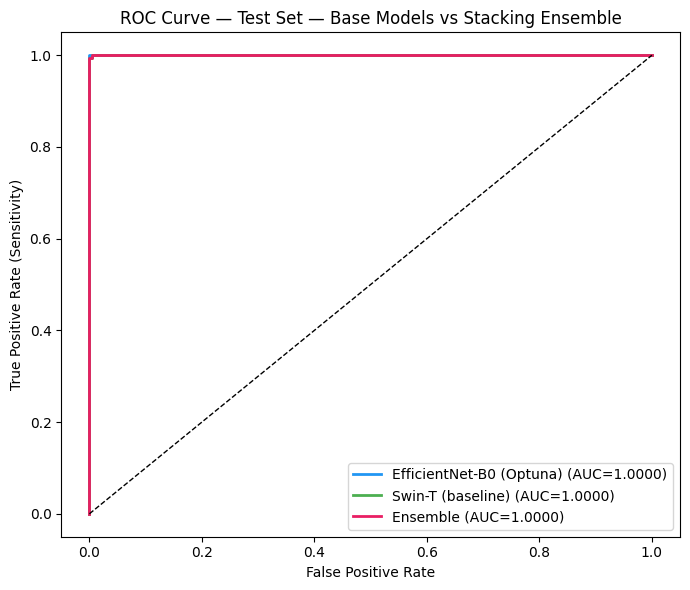

Saved nb08_roc_comparison.png


In [13]:
# Cell 13 — ROC curve: all three, test set
plt.figure(figsize=(7, 6))
for name, true, probs, color in [
    ("EfficientNet-B0 (Optuna)", eff_test_true, eff_test_probs, "#2196F3"),
    ("Swin-T (baseline)", swin_test_true, swin_test_probs, "#4CAF50"),
    ("Ensemble", y_meta_test, ensemble_test_probs, "#E91E63"),
]:
    fpr, tpr, _ = roc_curve(true, probs)
    auc_val = roc_auc_score(true, probs)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.4f})", color=color)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — Test Set — Base Models vs Stacking Ensemble")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "nb08_roc_comparison.png", dpi=150)
plt.show()
print("Saved nb08_roc_comparison.png")

In [14]:
# Cell 14 — Save results JSON
results = {
    "base_model_selection_rationale": (
        "EfficientNet-B0 uses its Optuna-tuned Stage 2 head (NB07): tuning "
        "improved sensitivity (0.9864->1.0000) and ECE (0.0159->0.0041) with "
        "a small specificity trade-off. Swin-T uses its NB05 baseline "
        "Stage 2 head: Optuna tuning degraded F1, specificity, FPR and ECE "
        "relative to baseline (NB07 Cell 15), so the baseline is the "
        "stronger validated configuration for this backbone. Each base "
        "learner's configuration was selected independently on validation "
        "performance rather than applying Optuna uniformly."
    ),
    "base_models": {
        "efficientnet_b0": {
            "tuning": "optuna",
            "attn_dim": EFFNET_ATTN_DIM,
            "dropout": EFFNET_DROPOUT,
            "threshold": EFFNET_THRESHOLD,
            "test_metrics": eff_test_metrics,
        },
        "swin_t": {
            "tuning": "baseline_untuned",
            "attn_dim": SWINT_ATTN_DIM,
            "dropout": SWINT_DROPOUT,
            "threshold": SWINT_THRESHOLD,
            "test_metrics": swin_test_metrics,
        },
    },
    "meta_learner": {
        "type": "logistic_regression",
        "cv_folds": 5,
        "oof_val_auc": float(oof_val_auc),
        "coef_efficientnet_b0": float(meta_lr_final.coef_[0][0]),
        "coef_swin_t": float(meta_lr_final.coef_[0][1]),
        "intercept": float(meta_lr_final.intercept_[0]),
        "calibrated_threshold": ensemble_threshold,
    },
    "ensemble_test_metrics": test_metrics,
}

with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=2)
print("Saved:", RESULTS_JSON)

Saved: /kaggle/working/nb08_ensemble_results.json


In [15]:
# Cell 15 — Final summary
print("=" * 55)
print("  NB08 — STACKING ENSEMBLE — FINAL RESULTS")
print("=" * 55)
print(f"  Base models  : EfficientNet-B0 (Optuna) + Swin-T (baseline)")
print(f"  OOF val AUC  : {oof_val_auc:.4f}")
print(f"  Threshold    : {ensemble_threshold:.4f}")
print()
print("  Test set (calibrated threshold):")
for k in ["auc", "f1", "sensitivity", "specificity", "fpr", "ece"]:
    print(f"    {k:15s}: {test_metrics[k]:.4f}")
print("=" * 55)

  NB08 — STACKING ENSEMBLE — FINAL RESULTS
  Base models  : EfficientNet-B0 (Optuna) + Swin-T (baseline)
  OOF val AUC  : 0.9901
  Threshold    : 0.5750

  Test set (calibrated threshold):
    auc            : 1.0000
    f1             : 0.9833
    sensitivity    : 1.0000
    specificity    : 0.9784
    fpr            : 0.0216
    ece            : 0.0365
